# GFlowNet Training Analysis

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict

# Import GFlowNet modules
from gfn import TrainingResult, HitTrajectory
from gfn.visualization import plot_training_curves

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Load Training Results

In [2]:
RESULT_PATH = 'results/LET7_10bp_FLDB_results_20260131_034422.pkl'  # conservation weighted

import pickle
result_pkl = Path(RESULT_PATH)
if result_pkl.exists():
    with open(result_pkl, 'rb') as f:
        loaded_data = pickle.load(f)
    
    if isinstance(loaded_data, dict):
        hit_trajectories = None
        if 'hit_trajectories' in loaded_data and loaded_data['hit_trajectories']:
            hit_trajectories = [HitTrajectory.from_dict(h) for h in loaded_data['hit_trajectories']]
        
        result = TrainingResult(
            model=None,
            losses=loaded_data.get('losses', []),
            logZs=loaded_data.get('logZs', []),
            sampled_states=[],
            objective='FL-DB',
            hit_rates=loaded_data.get('hit_rates'),
            target_coverages=loaded_data.get('target_coverages'),
            n_targets=loaded_data.get('config', {}).get('n_targets', 0),
            hit_trajectories=hit_trajectories,
        )
    else:
        result = loaded_data
    
    print(f'Loaded: {result.objective}, {len(result.losses)} iterations, {result.n_targets} targets')
    print(f'  {result.total_hits} total hits, {result.n_unique_targets_hit} unique targets hit')
    if result.hit_rates:
        print(f'  Final hit rate: {result.final_hit_rate*100:.4f}%')
    if result.target_coverages:
        print(f'  Final coverage: {result.final_target_coverage*100:.2f}%')
else:
    print(f'File not found: {result_pkl}')

Loaded: FL-DB, 500 iterations, 58 targets
  142 total hits, 43 unique targets hit
  Final hit rate: 0.0000%
  Final coverage: 74.14%


## Hit Trajectory Analysis

In [3]:
def analyze_hits(result: TrainingResult):
    """Analyze hit trajectories and print summary statistics."""
    if not result.hit_trajectories:
        print("No hit trajectories recorded.")
        return None
    
    stats = result.get_hit_stats()
    
    print(f"Total Hits: {stats['total_hits']}")
    print(f"Unique Targets Hit: {stats['unique_targets']} / {result.n_targets}")
    print(f"Coverage: {stats['unique_targets'] / result.n_targets * 100:.1f}%")
    print(f"First Hit at Iteration: {stats['first_hit_iteration']}")
    print(f"Last Hit at Iteration: {stats['last_hit_iteration']}")
    
    hits_counts = list(stats['hits_per_target'].values())
    print(f"\nHits per Target:")
    print(f"  Min: {min(hits_counts)}, Max: {max(hits_counts)}, Mean: {np.mean(hits_counts):.1f}")
    
    return stats

if 'result' in dir() and result is not None:
    stats = analyze_hits(result)

Total Hits: 142
Unique Targets Hit: 43 / 58
Coverage: 74.1%
First Hit at Iteration: 1
Last Hit at Iteration: 498

Hits per Target:
  Min: 1, Max: 11, Mean: 3.3


## Unique Target Analysis

In [4]:
def get_unique_targets_summary(result: TrainingResult) -> pd.DataFrame:
    """Get a summary DataFrame of all unique hit targets with statistics."""
    if not result.hit_trajectories:
        print("No hit trajectories recorded.")
        return pd.DataFrame()
    
    target_stats = defaultdict(lambda: {
        'hit_count': 0,
        'first_hit_iter': float('inf'),
        'last_hit_iter': 0,
        'rewards': [],
        'batch_indices': []
    })
    
    for hit in result.hit_trajectories:
        seq_str = ''.join(c for c in hit.sequence if c != 'ε')
        stats = target_stats[seq_str]
        stats['hit_count'] += 1
        stats['first_hit_iter'] = min(stats['first_hit_iter'], hit.iteration)
        stats['last_hit_iter'] = max(stats['last_hit_iter'], hit.iteration)
        stats['rewards'].append(hit.reward)
        stats['batch_indices'].append(hit.batch_index)
    
    rows = []
    for seq, stats in target_stats.items():
        rows.append({
            'target': seq,
            'hit_count': stats['hit_count'],
            'first_hit_iter': stats['first_hit_iter'],
            'last_hit_iter': stats['last_hit_iter'],
            'avg_reward': np.mean(stats['rewards']),
            'sequence_len': len(seq)
        })
    
    df = pd.DataFrame(rows)
    df = df.sort_values('hit_count', ascending=False).reset_index(drop=True)
    return df

if 'result' in dir() and result is not None:
    unique_targets_df = get_unique_targets_summary(result)
    print(f"Unique targets hit: {len(unique_targets_df)} / {result.n_targets} "
          f"({len(unique_targets_df) / result.n_targets * 100:.1f}%)\n")
    display(unique_targets_df)

Unique targets hit: 43 / 58 (74.1%)



,target,hit_count,first_hit_iter,last_hit_iter,avg_reward,sequence_len
0,AGGUUGUAUG,11,100,470,0.9,10
1,AAGUUGUGUU,8,118,473,0.7,10
2,AGAUUGUAUA,7,11,468,0.9,10
3,AGGUUGUAUA,6,211,429,1.0,10
4,AGGUUUGUUA,6,165,474,0.7,10
5,AGGUUGUACA,5,121,493,0.9,10
6,AGGUUAUGUA,5,12,386,0.8,10
7,AGGUUAUAUU,5,13,426,0.8,10
8,AGGUUGUAUU,5,250,491,0.9,10
9,AGGUUGUUUA,5,114,489,0.9,10


## Trajectory Step-by-Step Analysis

In [5]:
from gfn import env as gfn_env
from gfn import use_preset

def print_trajectory_steps(result: TrainingResult, target_seq: str, hit_index: int = 0):
    """Print step-by-step sequence construction for a specific hit target."""
    matching_hits = []
    for hit in result.hit_trajectories:
        seq_str = ''.join(c for c in hit.sequence if c != 'ε')
        if seq_str == target_seq:
            matching_hits.append(hit)
    
    if not matching_hits:
        print(f"No hit found for target: {target_seq}")
        return
    
    print(f"Found {len(matching_hits)} hit(s) for target: {target_seq}")
    
    if hit_index >= len(matching_hits):
        print(f"Hit index {hit_index} out of range. Using index 0.")
        hit_index = 0
    
    hit = matching_hits[hit_index]
    print(f"\nShowing hit #{hit_index + 1} (iteration {hit.iteration}, reward={hit.reward:.4f})")
    
    if hit.actions is None:
        print("No action trajectory recorded for this hit.")
        print(f"Final sequence: {target_seq}")
        return
    
    max_len = len(hit.sequence)
    state = [0, ['ε'] * max_len]
    
    print(f"\nStep 0 (initial): {''.join(state[1])}")
    
    for step, action_idx in enumerate(hit.actions):
        action = gfn_env.ACTIONS_LIST[action_idx]
        state = gfn_env.perform_action(state, action_idx)
        seq_display = ''.join(state[1])
        
        action_type = action[0]
        if action_type == 'insert':
            action_desc = f"insert '{action[2]}' at pos {action[1]}"
        elif action_type == 'delete':
            action_desc = f"delete at pos {action[1]}"
        else:
            action_desc = f"mutate pos {action[1]} to '{action[2]}'"
        
        log_pf = f", log_P_F={hit.log_P_Fs[step]:.3f}" if hit.log_P_Fs else ""
        print(f"Step {step + 1}: {seq_display}  [{action_desc}{log_pf}]")
    
    print(f"Final sequence: {''.join(c for c in state[1] if c != 'ε')}")

if 'result' in dir() and result is not None:
    use_preset('let7_pilot')
    
    TARGET_TO_ANALYZE = 'CGGUUGUAAA'
    print_trajectory_steps(result, TARGET_TO_ANALYZE, hit_index=0)

Found 1 hit(s) for target: CGGUUGUAAA

Showing hit #1 (iteration 285, reward=0.8000)

Step 0 (initial): εεεεεεεεεε
Step 1: Aεεεεεεεεε  [insert 'A' at pos 0, log_P_F=-0.255]
Step 2: AAεεεεεεεε  [insert 'A' at pos 1, log_P_F=-2.111]
Step 3: UAAεεεεεεε  [insert 'U' at pos 0, log_P_F=-3.523]
Step 4: CUAAεεεεεε  [insert 'C' at pos 0, log_P_F=-3.238]
Step 5: CGUAAεεεεε  [insert 'G' at pos 1, log_P_F=-2.361]
Step 6: CGUUAAεεεε  [insert 'U' at pos 3, log_P_F=-2.695]
Step 7: CGUGUAAεεε  [insert 'G' at pos 3, log_P_F=-3.459]
Step 8: CGUUGUAAεε  [insert 'U' at pos 2, log_P_F=-3.201]
Step 9: CGGUUGUAAε  [insert 'G' at pos 1, log_P_F=-2.606]
Step 10: CGGUUGUAAA  [insert 'A' at pos 8, log_P_F=-3.439]
Final sequence: CGGUUGUAAA


## State-Space Flow Graph (DAG)

In [6]:
import networkx as nx
from collections import defaultdict
from typing import Dict, List, Tuple, Set

def build_trajectory_graph(result: TrainingResult) -> Tuple[nx.DiGraph, Dict[str, int]]:
    """Build a directed graph from all hit trajectories."""
    G = nx.DiGraph()
    edge_counts = defaultdict(int)
    node_visits = defaultdict(int)
    
    use_preset('let7_pilot')
    
    for hit in result.hit_trajectories:
        if hit.actions is None:
            continue
            
        max_len = len(hit.sequence)
        state = [0, ['ε'] * max_len]
        
        prev_state_str = ''.join(state[1])
        node_visits[prev_state_str] += 1
        
        for action_idx in hit.actions:
            state = gfn_env.perform_action(state, action_idx)
            curr_state_str = ''.join(state[1])
            
            edge_counts[(prev_state_str, curr_state_str)] += 1
            node_visits[curr_state_str] += 1
            
            prev_state_str = curr_state_str
    
    for (src, dst), count in edge_counts.items():
        G.add_edge(src, dst, weight=count)
    
    for node in G.nodes():
        G.nodes[node]['visits'] = node_visits[node]
        G.nodes[node]['seq_len'] = sum(1 for c in node if c != 'ε')
    
    return G, dict(node_visits)

if 'result' in dir() and result is not None:
    G, node_visits = build_trajectory_graph(result)
    print(f"Nodes (unique states): {G.number_of_nodes()}")
    print(f"Edges (transitions): {G.number_of_edges()}")
    print(f"Total trajectories: {len([h for h in result.hit_trajectories if h.actions])}")
    
    top_states = sorted(node_visits.items(), key=lambda x: -x[1])[:10]
    print(f"\nTop 10 most visited states:")
    for state, visits in top_states:
        clean_state = state.replace('ε', '')
        print(f"  '{clean_state}' (len={len(clean_state)}): {visits} visits")

Nodes (unique states): 590
Edges (transitions): 821
Total trajectories: 142

Top 10 most visited states:
  '' (len=0): 142 visits
  'A' (len=1): 111 visits
  'AG' (len=2): 51 visits
  'AA' (len=2): 31 visits
  'AGU' (len=3): 30 visits
  'AU' (len=2): 27 visits
  'AGG' (len=3): 20 visits
  'U' (len=1): 19 visits
  'AGGU' (len=4): 18 visits
  'AGA' (len=3): 17 visits


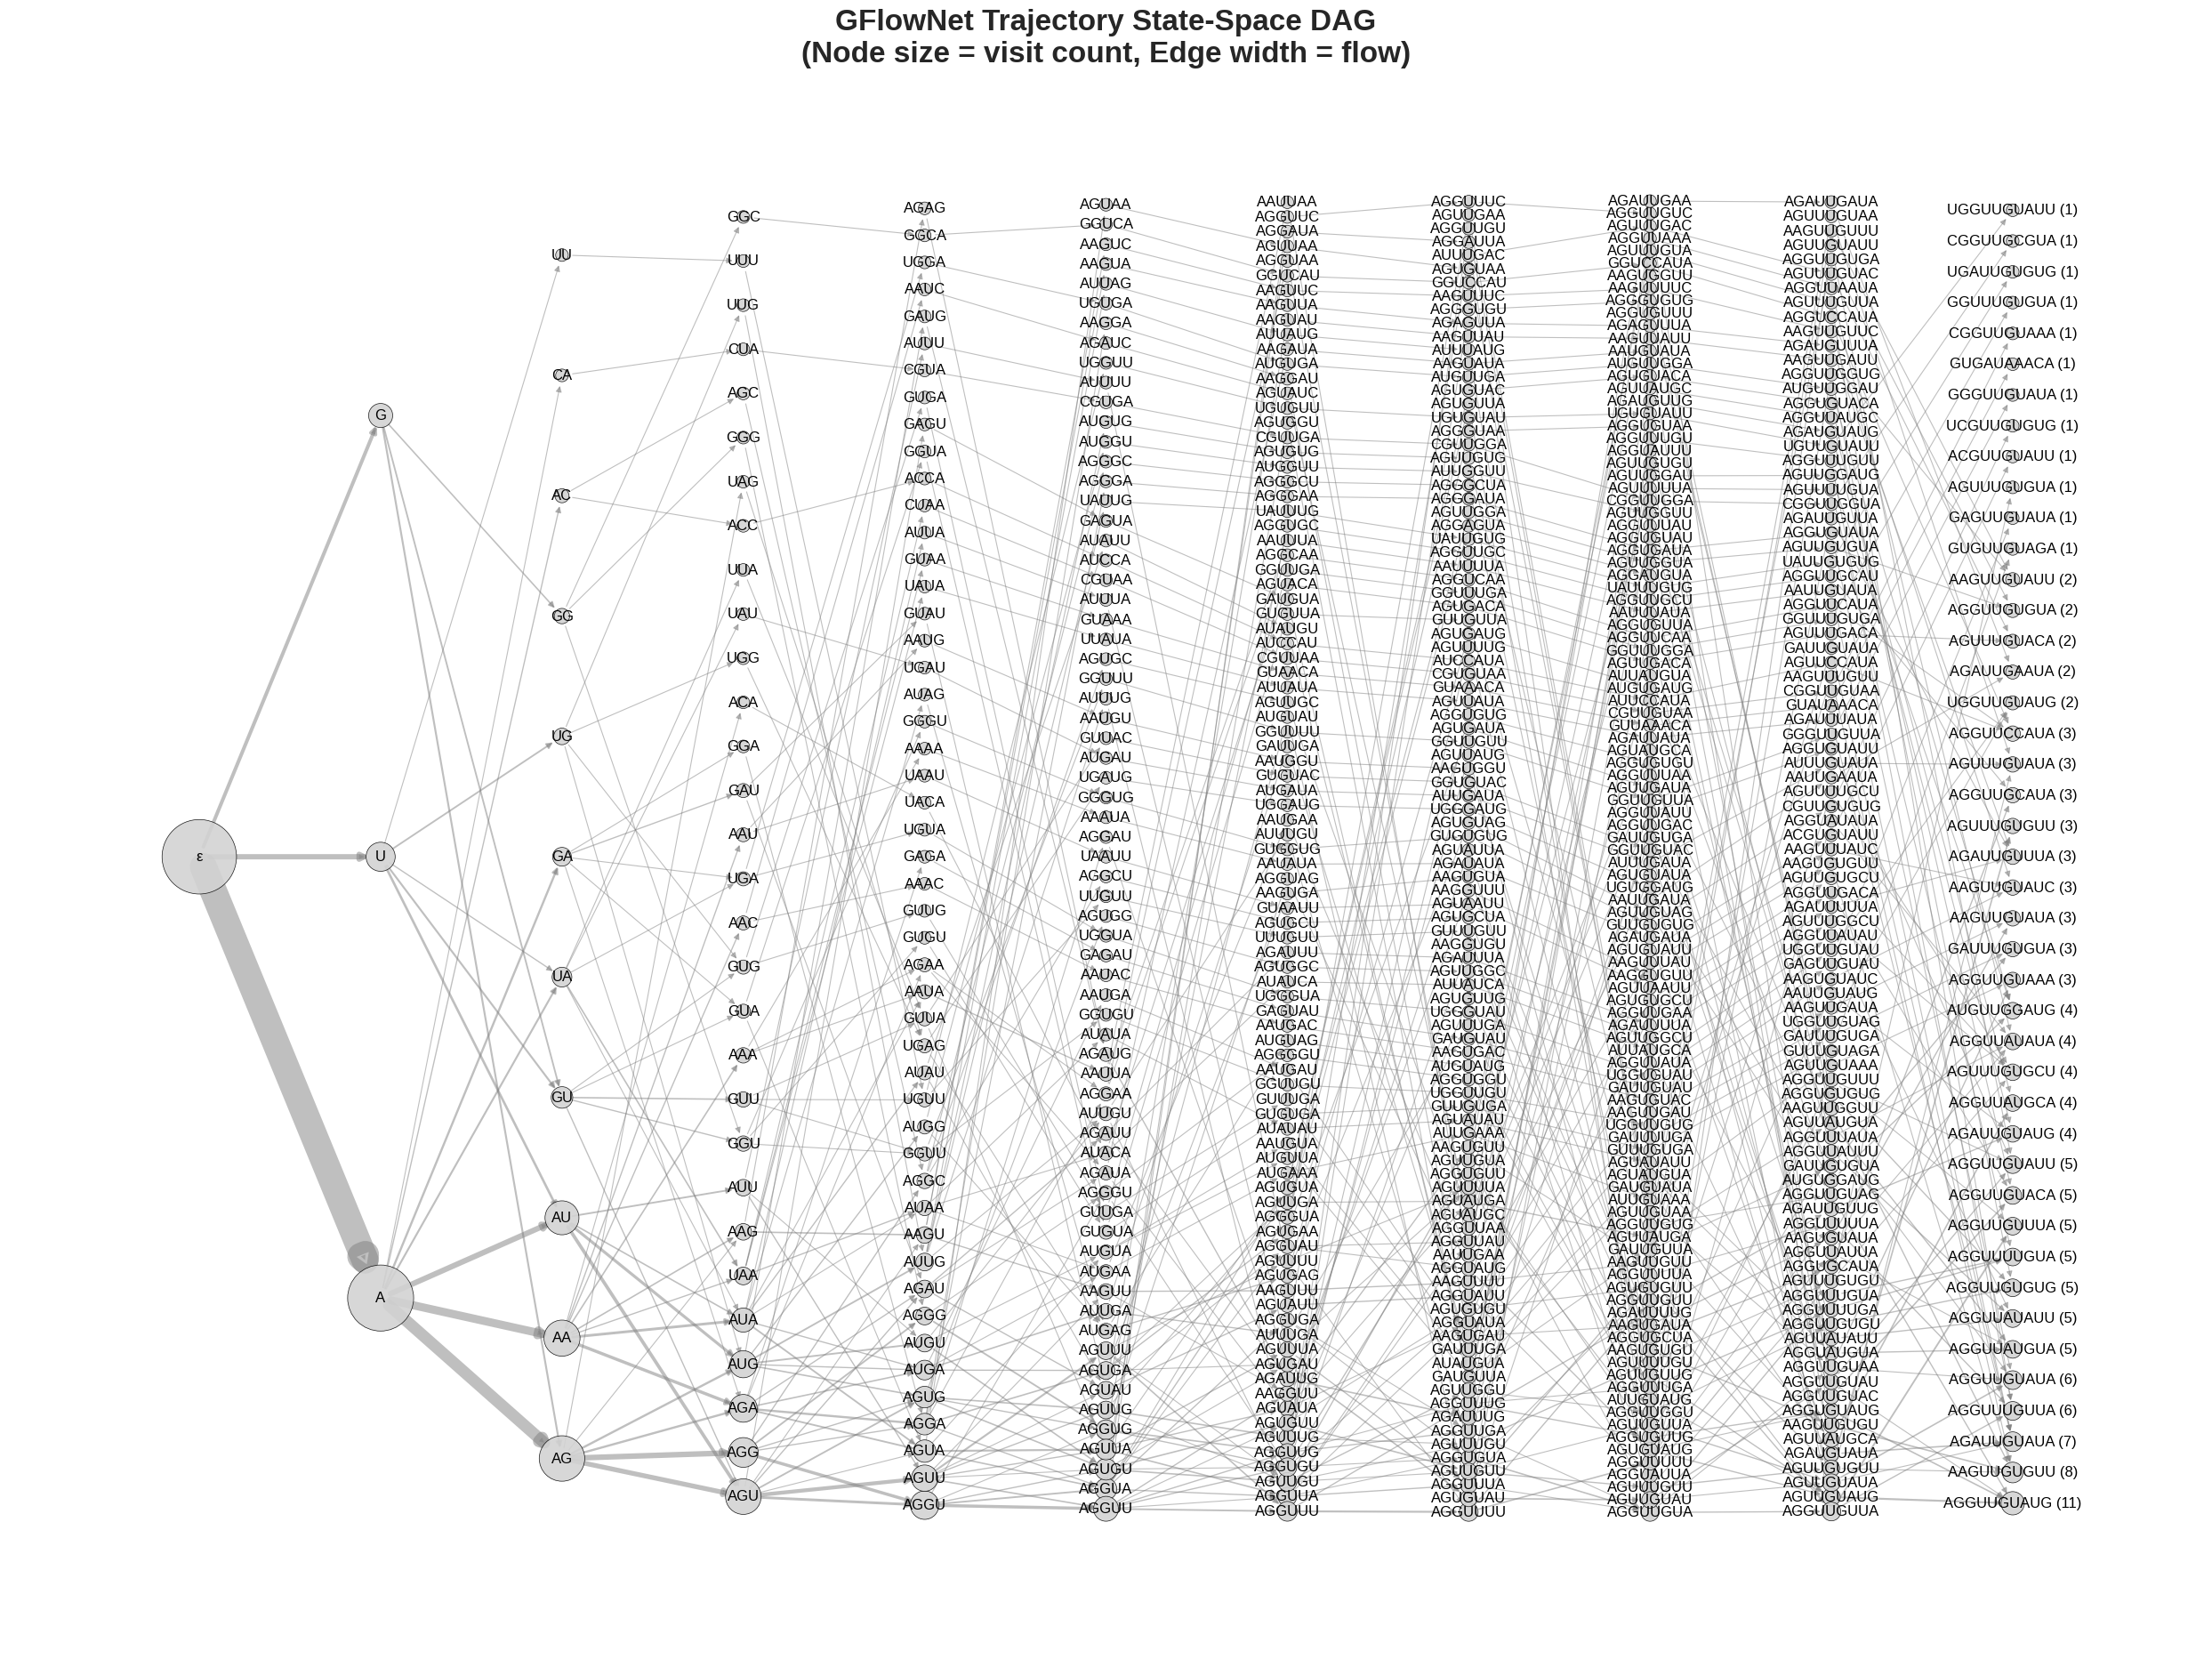

Saved to: results/LET7_10bp_hit_sequences_dag.pdf


In [7]:
def plot_trajectory_dag(G: nx.DiGraph, node_visits: Dict[str, int], 
                        figsize=(25, 19),
                        min_edge_width: float = 0.5, max_edge_width: float = 8.0,
                        node_color: str = 'lightgray',
                        leaf_order: list = None):
    """Plot the trajectory DAG with hierarchical layout based on sequence length."""
    if G.number_of_nodes() == 0:
        print("Empty graph, nothing to plot.")
        return
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    ax.set_facecolor('white')
    ax.grid(False)
    ax.axis('off')
    
    # Group nodes by sequence length (layer)
    layers = defaultdict(list)
    for node in G.nodes():
        seq_len = G.nodes[node]['seq_len']
        layers[seq_len].append(node)
    
    max_layer_idx = max(layers.keys())
    
    leaf_order_map = {}
    if leaf_order is not None:
        for i, seq in enumerate(leaf_order):
            leaf_order_map[seq] = i
    
    pos = {}
    max_layer_size = max(len(nodes) for nodes in layers.values())
    
    for layer_idx, nodes in sorted(layers.items()):
        n_nodes = len(nodes)
        
        if layer_idx == max_layer_idx and leaf_order is not None:
            nodes_sorted = sorted(nodes, key=lambda x: leaf_order_map.get(x.replace('ε', ''), 9999))
        else:
            nodes_sorted = sorted(nodes, key=lambda x: -node_visits.get(x, 0))
        
        for i, node in enumerate(nodes_sorted):
            x = layer_idx
            y = (i - (n_nodes - 1) / 2) * (max_layer_size / max(n_nodes, 1)) * 0.8
            pos[node] = (x, y)
    
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    if edge_weights:
        max_weight = max(edge_weights)
        min_weight = min(edge_weights)
        weight_range = max_weight - min_weight if max_weight > min_weight else 1
        
        edge_widths = [
            min_edge_width + (w - min_weight) / weight_range * (max_edge_width - min_edge_width)
            for w in edge_weights
        ]
    else:
        edge_widths = [1]
    
    node_sizes = [80 + node_visits.get(node, 1) * 25 for node in G.nodes()]
    
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        width=edge_widths,
        alpha=0.5,
        edge_color='gray',
        arrows=True,
        arrowsize=10,
    )
    
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_color,
        alpha=0.9,
        edgecolors='black',
        linewidths=0.5
    )
    
    labels = {}
    label_pos = {}
    for node in G.nodes():
        clean_seq = node.replace('ε', '')
        seq_len = G.nodes[node]['seq_len']
        
        if seq_len == max_layer_idx and clean_seq:
            hit_count = node_visits.get(node, 0)
            labels[node] = f"{clean_seq} ({hit_count})"
        else:
            labels[node] = clean_seq if clean_seq else 'ε'
        
        x, y = pos[node]
        label_pos[node] = (x, y - 0.0)
    
    nx.draw_networkx_labels(
        G, label_pos, labels, ax=ax,
        font_size=12,
        font_weight='normal'
    )
    
    fig.suptitle(
        'GFlowNet Trajectory State-Space DAG\n(Node size = visit count, Edge width = flow)', 
        fontsize=24, y=0.98, fontweight='bold'
    )
    
    plt.tight_layout()
    plt.show()
    
    return fig

if 'G' in dir() and G is not None:
    leaf_order = tree_leaf_order if 'tree_leaf_order' in dir() else None
    if leaf_order:
        print(f"Using tree leaf order for DAG alignment ({len(leaf_order)} sequences)")
    
    fig = plot_trajectory_dag(G, node_visits, min_edge_width=0.8, max_edge_width=22, 
                              leaf_order=leaf_order)
    
    fig.savefig('results/LET7_10bp_hit_sequences_dag.pdf', format='pdf', bbox_inches='tight', dpi=150)
    print('Saved to: results/LET7_10bp_hit_sequences_dag.pdf')

## Phylogenetic Analysis of Hit Targets

In [9]:
import json
import toytree
import toyplot

with open('data/LET7_10bp_targets.json', 'r') as f:
    species_to_seq = json.load(f)

seq_to_species = {}
for species, seq in species_to_seq.items():
    if seq not in seq_to_species:
        seq_to_species[seq] = []
    seq_to_species[seq].append(species)

print(f'Total species: {len(species_to_seq)}')
print(f'Unique 10bp sequences: {len(seq_to_species)}')

Total species: 612
Unique 10bp sequences: 58


In [10]:
if 'result' in dir() and result is not None and result.hit_trajectories:
    unique_hit_seqs = set()
    for hit in result.hit_trajectories:
        seq = ''.join(hit.sequence)
        unique_hit_seqs.add(seq)
    
    hit_species = set()
    for seq in unique_hit_seqs:
        if seq in seq_to_species:
            hit_species.update(seq_to_species[seq])
    
    print(f'Unique hit sequences: {len(unique_hit_seqs)}')
    print(f'Species with hit sequences: {len(hit_species)}')
else:
    print('No hit trajectories available.')

Unique hit sequences: 43
Species with hit sequences: 583


In [11]:
tree = toytree.tree('phylogeny/miRNA_iqtree/miRNA_LET7.treefile')

print(f'Tree: {tree.ntips} tips')

tree_tips = set(tree.get_tip_labels())
target_species = set(species_to_seq.keys())

in_tree = target_species & tree_tips
not_in_tree = target_species - tree_tips

print(f'Target species in tree: {len(in_tree)}/{len(target_species)}')
if not_in_tree:
    print(f'Species not in tree: {list(not_in_tree)[:5]}...')

Tree: 627 tips
Target species in tree: 612/612


In [12]:
if 'hit_species' in dir() and hit_species and 'subtree' in dir():
    seq_hit_counts = {}
    for hit in result.hit_trajectories:
        seq = ''.join(hit.sequence)
        seq_hit_counts[seq] = seq_hit_counts.get(seq, 0) + 1
    
    print(f'Top 10 most frequently hit sequences:')
    for seq, count in sorted(seq_hit_counts.items(), key=lambda x: -x[1])[:10]:
        species_list = seq_to_species.get(seq, [])
        print(f'  {seq}: {count} hits ({len(species_list)} species)')
    
    from collections import Counter
    hit_seq_list = [''.join(h.sequence) for h in result.hit_trajectories]
    seq_counter = Counter(hit_seq_list)
    
    print(f'\nTotal hits: {len(hit_seq_list)}')
    print(f'Unique sequences hit: {len(seq_counter)}')
    print(f'Most common: {seq_counter.most_common(1)[0]}')
    print(f'Species covered: {len(hit_species)}/{len(target_species)} ({len(hit_species)/len(target_species)*100:.1f}%)')

In [13]:
import numpy as np
from scipy.cluster.hierarchy import linkage, to_tree
from scipy.spatial.distance import squareform
import toytree

unique_hit_seqs = set()
for hit in result.hit_trajectories:
    seq = ''.join(hit.sequence)
    unique_hit_seqs.add(seq)

sequences = list(unique_hit_seqs)
n = len(sequences)
print(f"Building tree from {n} unique sequences")

def get_species_label(seq, max_show=3):
    """Format species label: (Nsp, sp1, sp2, sp3, ...)"""
    species_set = seq_to_species.get(seq, set())
    if not species_set:
        return ''
    
    n_sp = len(species_set)
    species_prefixes = sorted(set(sp.split('-')[0] for sp in species_set))
    shown_species = species_prefixes[:max_show]
    species_str = ', '.join(shown_species)
    
    if len(species_prefixes) > max_show:
        return f"({n_sp}sp, {species_str}, ...)"
    else:
        return f"({n_sp}sp, {species_str})"

seq_labels = []
for seq in sequences:
    sp_label = get_species_label(seq, max_show=3)
    if sp_label:
        label = f"{seq} {sp_label}"
    else:
        label = seq
    seq_labels.append(label)

# Hamming distance matrix
def hamming_distance(s1, s2):
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        d = hamming_distance(sequences[i], sequences[j])
        dist_matrix[i, j] = dist_matrix[j, i] = d

print(f"Distance range: {dist_matrix[dist_matrix > 0].min():.0f} - {dist_matrix.max():.0f}")

# UPGMA clustering
condensed = squareform(dist_matrix)
Z = linkage(condensed, method='average')

from scipy.cluster.hierarchy import leaves_list
tree_leaf_indices = leaves_list(Z)
tree_leaf_order = [sequences[i] for i in tree_leaf_indices]

def linkage_to_newick(Z, labels):
    """Convert scipy linkage matrix to Newick string."""
    n = len(labels)
    quoted_labels = [f"'{lbl}'" for lbl in labels]
    nodes = {i: quoted_labels[i] for i in range(n)}
    
    for i, (left, right, dist, count) in enumerate(Z):
        left, right = int(left), int(right)
        new_node = f"({nodes[left]}:{dist/2:.2f},{nodes[right]}:{dist/2:.2f})"
        nodes[n + i] = new_node
    
    return nodes[2*n - 2] + ";"

newick = linkage_to_newick(Z, seq_labels)

tree = toytree.tree(newick)

canvas, axes, mark = tree.draw(
    height=700,
    width=1100,
    tip_labels_align=True,
    tip_labels_style={'font-size': '10px', 'font-family': 'monospace'},
    node_sizes=6,
    node_colors='lightblue',
)

axes.label.text = f'GFlowNet Hit Sequences Tree (n={n}, UPGMA, Hamming distance)'
axes.label.style = {'font-size': '13px', 'font-weight': 'bold'}

import toyplot.pdf
toyplot.pdf.render(canvas, 'results/LET7_10bp_hit_sequences_tree.pdf')
print('Saved to: results/LET7_10bp_hit_sequences_tree.pdf')

Building tree from 43 unique sequences
Distance range: 1 - 9
Saved to: results/LET7_10bp_hit_sequences_tree.pdf


## Hit Count vs Species Count (Conservation)

Unique sequences hit: 43

       hit_count  species_count
count  43.000000      43.000000
mean    3.302326      13.558140
std     2.209664      33.932217
min     1.000000       1.000000
25%     1.000000       1.000000
50%     3.000000       2.000000
75%     5.000000       8.000000
max    11.000000     208.000000

Correlation:
  Spearman: r = 0.509, p = 0.0005
  Pearson:  r = 0.381, p = 0.0116


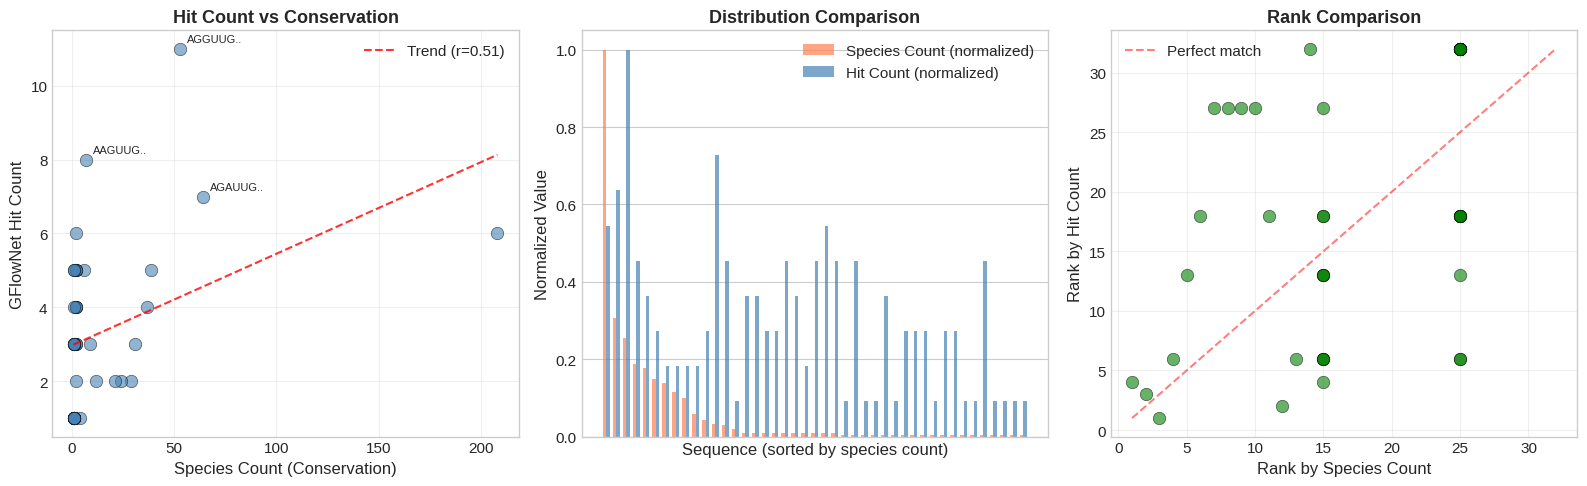


Saved to: results/LET7_10bp_conservation_vs_hits.pdf

Top 10 by Hit Count:
  sequence  hit_count  species_count
AGGUUGUAUG         11             53
AAGUUGUGUU          8              7
AGAUUGUAUA          7             64
AGGUUGUAUA          6            208
AGGUUUGUUA          6              2
AGGUUGUGUG          5             39
AGGUUGUUUA          5              6
AGGUUGUAUU          5              2
AGGUUGUACA          5              2
AGGUUAUAUU          5              2


In [14]:
from scipy.stats import spearmanr, pearsonr

comparison_data = []

seq_hit_counts = {}
for hit in result.hit_trajectories:
    seq = ''.join(c for c in hit.sequence if c != 'ε')
    seq_hit_counts[seq] = seq_hit_counts.get(seq, 0) + 1

for seq, hit_count in seq_hit_counts.items():
    species_list = seq_to_species.get(seq, [])
    species_count = len(species_list)
    comparison_data.append({
        'sequence': seq,
        'hit_count': hit_count,
        'species_count': species_count
    })

df_compare = pd.DataFrame(comparison_data)
df_compare = df_compare.sort_values('species_count', ascending=False)

print(f"Unique sequences hit: {len(df_compare)}\n")
print(df_compare.describe())

hit_counts = df_compare['hit_count'].values
species_counts = df_compare['species_count'].values

spearman_corr, spearman_p = spearmanr(species_counts, hit_counts)
pearson_corr, pearson_p = pearsonr(species_counts, hit_counts)

print(f"\nCorrelation:")
print(f"  Spearman: r = {spearman_corr:.3f}, p = {spearman_p:.4f}")
print(f"  Pearson:  r = {pearson_corr:.3f}, p = {pearson_p:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter plot
ax1 = axes[0]
ax1.scatter(species_counts, hit_counts, alpha=0.6, s=80, c='steelblue', edgecolors='black', linewidth=0.5)
z = np.polyfit(species_counts, hit_counts, 1)
p = np.poly1d(z)
x_line = np.linspace(species_counts.min(), species_counts.max(), 100)
ax1.plot(x_line, p(x_line), 'r--', alpha=0.8, label=f'Trend (r={spearman_corr:.2f})')
ax1.set_xlabel('Species Count (Conservation)', fontsize=12)
ax1.set_ylabel('GFlowNet Hit Count', fontsize=12)
ax1.set_title('Hit Count vs Conservation', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

for _, row in df_compare.nlargest(3, 'hit_count').iterrows():
    ax1.annotate(row['sequence'][:6]+'..', 
                 (row['species_count'], row['hit_count']),
                 textcoords="offset points", xytext=(5,5), fontsize=8)

# Normalized distribution comparison
ax2 = axes[1]
df_sorted = df_compare.sort_values('species_count', ascending=False)
x = np.arange(len(df_sorted))
width = 0.35

norm_species = df_sorted['species_count'] / df_sorted['species_count'].max()
norm_hits = df_sorted['hit_count'] / df_sorted['hit_count'].max()

ax2.bar(x - width/2, norm_species, width, label='Species Count (normalized)', alpha=0.7, color='coral')
ax2.bar(x + width/2, norm_hits, width, label='Hit Count (normalized)', alpha=0.7, color='steelblue')
ax2.set_xlabel('Sequence (sorted by species count)', fontsize=12)
ax2.set_ylabel('Normalized Value', fontsize=12)
ax2.set_title('Distribution Comparison', fontsize=13, fontweight='bold')
ax2.legend()
ax2.set_xticks([])

# Rank comparison
ax3 = axes[2]
df_compare['rank_species'] = df_compare['species_count'].rank(ascending=False, method='min')
df_compare['rank_hits'] = df_compare['hit_count'].rank(ascending=False, method='min')

ax3.scatter(df_compare['rank_species'], df_compare['rank_hits'], alpha=0.6, s=80, c='green', edgecolors='black', linewidth=0.5)
max_rank = max(df_compare['rank_species'].max(), df_compare['rank_hits'].max())
ax3.plot([1, max_rank], [1, max_rank], 'r--', alpha=0.5, label='Perfect match')
ax3.set_xlabel('Rank by Species Count', fontsize=12)
ax3.set_ylabel('Rank by Hit Count', fontsize=12)
ax3.set_title('Rank Comparison', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/LET7_10bp_conservation_vs_hits.pdf', format='pdf', bbox_inches='tight', dpi=150)
plt.show()

print('\nSaved to: results/LET7_10bp_conservation_vs_hits.pdf')

print("\nTop 10 by Hit Count:")
print(df_compare.nlargest(10, 'hit_count')[['sequence', 'hit_count', 'species_count']].to_string(index=False))